# MVP — Sistema de Triaje / Detección de Fraude (Híbrido: Tabular + NLP)

Este notebook es el **entregable MVP** (pre-producción). Demuestra un flujo end-to-end de detección de fraude combinando:

- **XGBoost** para variables tabulares.
- **DistilBERT (feature extraction, sin fine-tuning)** para el texto de la reclamación.
- **Meta-learner (Keras)** para ensamblar ambas probabilidades (Stacking).

> Nota: la “productización” (API, CI/CD, registro de modelos, monitorización) se describe como próximos pasos, pero **no se implementa** en el MVP.

## Contrato del MVP (qué incluye / qué NO incluye)

**Incluye**

- Entrenamiento de modelos base: XGBoost (tabular) y una red densa sobre embeddings (NLP).
- Ensamble Stacking con meta-learner (Keras).
- Evaluación final en un conjunto de test y demo de inferencia con tabla de ejemplos.

**No incluye (fuera de alcance del MVP)**

- Interfaz gráfica con formularios complejos (ipywidgets con pestañas, CSS/HTML).
- Despliegue a producción (API, Docker, CI/CD).
- Registro/versionado de modelos, monitorización, retraining automático.

**Criterio de éxito**

- El notebook corre de inicio a fin (en Colab) y produce métricas del modelo híbrido + una demo de predicción reproducible.

In [1]:
# ================================
# 0) Imports y dependencias
# ================================
import numpy as np
import pandas as pd
import random
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import xgboost as xgb
import torch

from IPython.display import display
from google.colab import drive
from transformers import AutoTokenizer, AutoModel

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix, f1_score, roc_curve
    )

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

plt.style.use('ggplot')

In [2]:
# ================================
# 0.1) Reproducibilidad
# ================================
def set_random_seed(seed_value: int = 42) -> None:
    np.random.seed(seed_value)
    tf.random.set_seed(seed_value)
    torch.manual_seed(seed_value)
    random.seed(seed_value)
    print(f"[*] Semillas aleatorias fijadas en {seed_value}.")

set_random_seed(42)

[*] Semillas aleatorias fijadas en 42.


## 1) Datos y preprocesamiento (tabular)

Este MVP está orientado a ejecución en **Google Colab** con el dataset en Drive. Ajusta `file_path` a la ubicación real del Excel.

In [6]:
# ================================
# 1.1) Carga de datos
# ================================
print("\n[*] Cargando datos...")
drive.mount('/content/drive/')

# Ajusta esta ruta a tu Drive
file_path = '/content/drive/MyDrive/Colab Notebooks/UNIR/Seminario/dataset_reclamos_ia_ruidoso_extremo.xlsx'
df = pd.read_excel(file_path)

print(f"[*] Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas")
df.head(3)


[*] Cargando datos...
Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
[*] Dataset cargado: 5,000 filas x 26 columnas


,Customer_Age,Claim_Amount,Claim_History_Count_This_Policy,Claim_Frequency_Last_12_Month,Claim_Description,Gender,Last_Purchase_History_Date,Policy_Start_Date,Policy_Renewal_Date,Coverage_Amount,...,Coverage_description,LossType_Description,Branch_Description,Beneficiary_Type_Description,WorkShop_Name,Insured_Zip,Vehicle_Make,Vehicle_Model,Model_Year,Prediccion_Fraude
0,74,116281.22,0,1,"El 15 de octubre, mientras manejaba por la Av....",M,2025-01-05,2025-07-21,2026-07-21,1756012.19,...,Cobertura Completa,Pérdida Parcial,Sucursal Santiago,Banco/Financiera,Auto Pintura J&J,51100,Rivian,R1T,2021,0
1,44,68880.28,0,0,"El 24 de octubre, tuve un accidente mientras c...",F,2023-12-30,2024-06-02,2025-06-02,475779.24,...,Robo,Pérdida Parcial,Sucursal La Vega,Asegurado,Auto Pintura J&J,10508,Kia,Telluride,2024,0
2,23,351069.98,1,1,"El pasado 15 de octubre, tuve un accidente con...",F,2023-08-09,2024-01-17,2025-01-16,995928.65,...,Rotura de Cristal,Pérdida Parcial,Punta Cana,Asegurado,Auto Pintura J&J,11503,Maserati,Quattroporte,2024,0


In [7]:
# ================================
# 1.2) Feature Engineering + Encoding
# ================================
print("[*] Feature Engineering Tabular...")

# Columnas de fecha (se usan para variables derivadas)
date_cols = ['Incident_Date', 'Date_Reported', 'Policy_Start_Date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Variables de tiempo
df['Report_Delay'] = (df['Date_Reported'] - df['Incident_Date']).dt.days.fillna(0)
df['Days_Since_Policy'] = (df['Incident_Date'] - df['Policy_Start_Date']).dt.days.fillna(0)

max_model_year = df['Model_Year'].max()
df['Car_Age'] = max_model_year - df['Model_Year']

# Eliminar datetime (ya usamos su información) y columnas no útiles
df = df.select_dtypes(exclude=['datetime64'])
df = df.drop(columns=['Claim_ID', 'Policy_Number', 'Last_Purchase_History_Date'], errors='ignore')

# Label encoding para categóricas (excepto texto libre)
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    if col != 'Claim_Description':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

# X tabular / y / texto
X_tab_df = df.drop(columns=['Claim_Description', 'Prediccion_Fraude'])
X_tab_features = X_tab_df.columns.tolist()
X_tab = X_tab_df.values
y = df['Prediccion_Fraude'].values
text_data = df['Claim_Description'].astype(str).tolist()

print(f"[*] Features tabulares: {len(X_tab_features)} | Textos: {len(text_data)}")

[*] Feature Engineering Tabular...
[*] Features tabulares: 23 | Textos: 5000


### EDA mínimo (solo lo necesario para justificar decisiones del modelo)

En el MVP nos limitamos a:

- forma del dataset,
- nulos,
- **desbalance de clases** (justifica `scale_pos_weight` y `class_weight`).

El EDA completo puede vivir en un notebook separado si el equipo lo requiere.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Customer_Age                     5000 non-null   int64  
 1   Claim_Amount                     5000 non-null   float64
 2   Claim_History_Count_This_Policy  5000 non-null   int64  
 3   Claim_Frequency_Last_12_Month    5000 non-null   int64  
 4   Claim_Description                5000 non-null   object 
 5   Gender                           5000 non-null   int64  
 6   Policy_Renewal_Date              5000 non-null   int64  
 7   Coverage_Amount                  5000 non-null   float64
 8   Premium_Amount                   5000 non-null   float64
 9   Insured_Inception_Date           5000 non-null   int64  
 10  Insured_MaritalStatus            5000 non-null   int64  
 11  Insured_Occupation               5000 non-null   int64  
 12  Coverage_description

,0


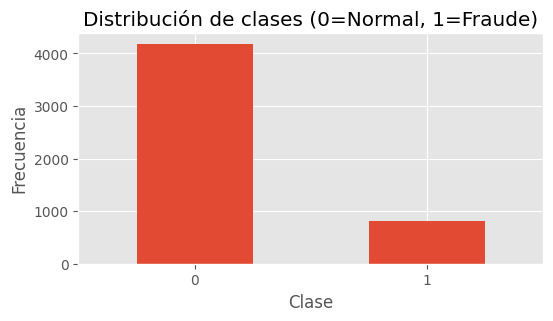

In [8]:
# ----------------
# EDA mínimo
# ----------------
print(df.info())

missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].head(20))

class_counts = pd.Series(y).value_counts().sort_index()
ax = class_counts.plot(kind='bar', figsize=(6, 3), title='Distribución de clases (0=Normal, 1=Fraude)')
ax.set_xlabel('Clase')
ax.set_ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.show()

## 2) NLP como extracción de características (DistilBERT)

En el MVP **no reentrenamos** DistilBERT: lo usamos como *feature extractor* para convertir la descripción del siniestro en un embedding de 768 dimensiones.

Esto acelera el desarrollo (menos ingeniería) a costa de que la extracción de embeddings sea el paso más pesado computacionalmente.

In [9]:
# ================================
# 2.1) Embeddings con DistilBERT (PyTorch)
# ================================
print("\n[*] Cargando DistilBERT (feature extraction)...")
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-multilingual-cased")
distilbert_model = AutoModel.from_pretrained("distilbert-base-multilingual-cased")
distilbert_model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
distilbert_model.to(device)
print(f"[*] Dispositivo: {device}")

def extract_embeddings(text_list, batch_size: int = 32, max_length: int = 120) -> np.ndarray:
    all_embeddings = []
    for i in range(0, len(text_list), batch_size):
        batch = text_list[i:i + batch_size]
        inputs = tokenizer(
            batch, padding=True, truncation=True, max_length=max_length, return_tensors="pt"
        ).to(device)
        with torch.no_grad():
            outputs = distilbert_model(**inputs)
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_embeddings)
    return np.vstack(all_embeddings)

print("[*] Extrayendo embeddings para todos los textos...")
X_text_embeddings = extract_embeddings(text_data)
print(f"[*] Embeddings: {X_text_embeddings.shape}")


[*] Cargando DistilBERT (feature extraction)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[*] Dispositivo: cuda
[*] Extrayendo embeddings para todos los textos...
[*] Embeddings: (5000, 768)


## 3) Split estratificado para Stacking (evitar leakage)

Dividimos en 4 conjuntos:

- `train`: entrena modelos base.
- `val`: valida/early-stopping modelos base.
- `meta`: genera predicciones out-of-fold para entrenar el meta-learner.
- `test`: evaluación final no sesgada.

In [10]:
# ================================
# 3.1) Split train/val/meta/test
# ================================
indices = np.arange(len(y))
idx_temp, idx_test, y_temp, y_test = train_test_split(
    indices, y, test_size=0.20, random_state=42, stratify=y
 )
idx_base, idx_meta, y_base, y_meta = train_test_split(
    idx_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
 )
idx_train, idx_val, y_train, y_val = train_test_split(
    idx_base, y_base, test_size=0.20, random_state=42, stratify=y_base
 )

X_tab_train, X_tab_val, X_tab_meta, X_tab_test = X_tab[idx_train], X_tab[idx_val], X_tab[idx_meta], X_tab[idx_test]
X_text_train = X_text_embeddings[idx_train]
X_text_val   = X_text_embeddings[idx_val]
X_text_meta  = X_text_embeddings[idx_meta]
X_text_test  = X_text_embeddings[idx_test]

print(f"Train: {len(idx_train)} | Val: {len(idx_val)} | Meta: {len(idx_meta)} | Test: {len(idx_test)}")

Train: 2400 | Val: 600 | Meta: 1000 | Test: 1000


In [11]:
# ================================
# 4) Utilidades de evaluación (MVP)
# ================================
def evaluate_and_plot(y_true, y_pred_prob, title: str, threshold: float = 0.5) -> None:
    y_pred_bin = (y_pred_prob > threshold).astype(int)
    auc = roc_auc_score(y_true, y_pred_prob)
    f1 = f1_score(y_true, y_pred_bin)
    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)
    print(f"F1: {f1:.4f} | AUC-ROC: {auc:.4f} | Threshold: {threshold}")
    print(classification_report(y_true, y_pred_bin, target_names=['Normal', 'Fraude']))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(confusion_matrix(y_true, y_pred_bin), annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title('Matriz de Confusión')

    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    axes[1].plot(fpr, tpr, lw=2, label=f"AUC={auc:.4f}")
    axes[1].plot([0, 1], [0, 1], linestyle='--', lw=1)
    axes[1].set_title('Curva ROC')
    axes[1].set_xlabel('FPR')
    axes[1].set_ylabel('TPR')
    axes[1].legend(loc='lower right')
    plt.show()

## 4) Modelos base + meta-learner (Stacking)

Entrenamos:

1. **XGBoost** sobre variables tabulares.
2. **Red densa (Keras)** sobre embeddings de texto.
3. **Meta-learner** que recibe (p_tabular, p_texto) y aprende la probabilidad final.

In [12]:
# ================================
# 4.1) Modelo base 1 — XGBoost (tabular)
# ================================
print("\n🧠 Entrenando XGBoost (Tabular)...")
scale_pos_weight = float(np.sum(y_train == 0) / np.sum(y_train == 1))
xgb_model = xgb.XGBClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=scale_pos_weight,
    eval_metric=["logloss"],
    random_state=42,
    n_jobs=-1,
 )
xgb_model.fit(
    X_tab_train, y_train,
    eval_set=[(X_tab_val, y_val)],
    verbose=False
 )
prob_xgb_test = xgb_model.predict_proba(X_tab_test)[:, 1]
print(f"[*] XGBoost listo. AUC (test): {roc_auc_score(y_test, prob_xgb_test):.4f}")


🧠 Entrenando XGBoost (Tabular)...
[*] XGBoost listo. AUC (test): 0.7975


In [13]:
# ================================
# 4.2) Modelo base 2 — NN (sobre embeddings)
# ================================
print("\n🧠 Entrenando NN (NLP sobre embeddings)...")

input_text = Input(shape=(768,), name="text_embedding_input")
x = Dense(128, activation='relu')(input_text)
x = Dropout(0.5)(x)
x = Dense(32, activation='relu')(x)
x = Dropout(0.4)(x)
output_text = Dense(1, activation='sigmoid')(x)

nn_text_model = Model(inputs=input_text, outputs=output_text)
nn_text_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
class_weights_dict = dict(
    enumerate(class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train))
 )

nn_text_model.fit(
    X_text_train, y_train,
    validation_data=(X_text_val, y_val),
    epochs=5,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping],
    verbose=1,
 )

prob_nn_test = nn_text_model.predict(X_text_test, verbose=0).flatten()
print(f"[*] NN listo. AUC (test): {roc_auc_score(y_test, prob_nn_test):.4f}")


🧠 Entrenando NN (NLP sobre embeddings)...
Epoch 1/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9079 - loss: 0.2773 - val_accuracy: 0.9700 - val_loss: 0.1033
Epoch 2/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9679 - loss: 0.1070 - val_accuracy: 0.9817 - val_loss: 0.0553
Epoch 3/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9800 - loss: 0.0642 - val_accuracy: 0.9850 - val_loss: 0.0341
Epoch 4/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0412 - val_accuracy: 0.9950 - val_loss: 0.0127
Epoch 5/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9892 - loss: 0.0286 - val_accuracy: 1.0000 - val_loss: 0.0047
[*] NN listo. AUC (test): 1.0000



🧠 Entrenando Meta-Learner (Stacking)...
Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.1600 - loss: 0.7518 - val_accuracy: 0.3300 - val_loss: 0.7292
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3762 - loss: 0.7119 - val_accuracy: 0.5950 - val_loss: 0.6965
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6200 - loss: 0.6810 - val_accuracy: 0.6950 - val_loss: 0.6713
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7962 - loss: 0.6566 - val_accuracy: 0.7900 - val_loss: 0.6509
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8763 - loss: 0.6363 - val_accuracy: 0.8400 - val_loss: 0.6330
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9075 - loss: 0.6182 - val_accuracy: 0.8850 - val_loss: 0.6165
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9212 - loss: 0.6015 - val_accuracy: 0.9000 - val_loss: 0.6004
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9225 - loss:

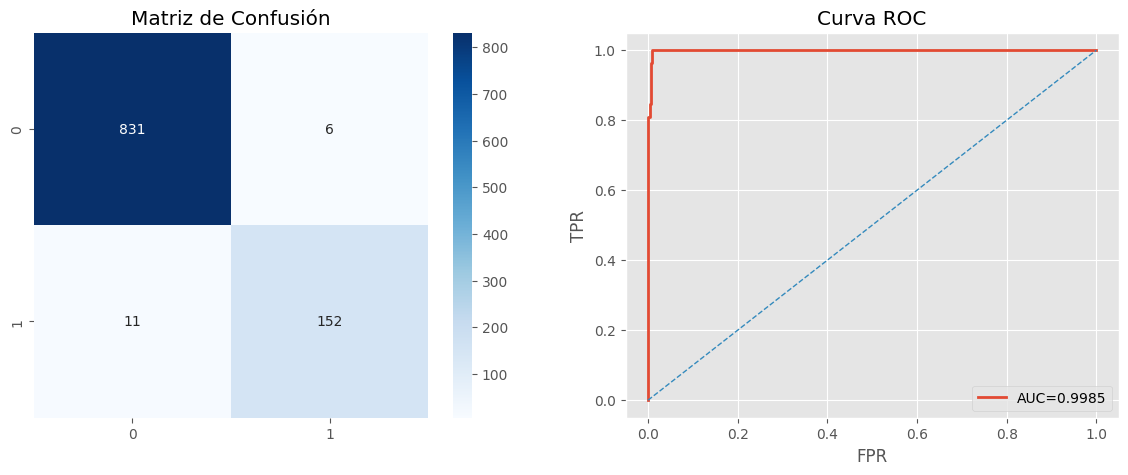


--- Comparación rápida (test) ---
AUC XGBoost: 0.7975
AUC NN NLP:  1.0000
AUC Stacking:0.9985


In [14]:
# ================================
# 4.3) Meta-learner (Stacking) + evaluación final
# ================================
print("\n🧠 Entrenando Meta-Learner (Stacking)...")

# Predicciones out-of-fold (meta set)
pred_meta_xgb = xgb_model.predict_proba(X_tab_meta)[:, 1]
pred_meta_nn = nn_text_model.predict(X_text_meta, verbose=0).flatten()

meta_input = Input(shape=(2,), name="meta_input")
m = Dense(8, activation='relu')(meta_input)
meta_output = Dense(1, activation='sigmoid')(m)

meta_nn = Model(inputs=meta_input, outputs=meta_output)
meta_nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
meta_nn.fit(
    np.column_stack((pred_meta_xgb, pred_meta_nn)),
    y_meta,
    validation_split=0.2,
    epochs=20,
    verbose=1,
 )

def predecir_fraude_stacking_batch(X_tab_nuevo: np.ndarray, textos: list[str]):
    p_tab = xgb_model.predict_proba(X_tab_nuevo)[:, 1]
    emb = extract_embeddings(textos)
    p_nlp = nn_text_model.predict(emb, verbose=0).flatten()
    meta_in = np.column_stack((p_tab, p_nlp))
    p_stack = meta_nn.predict(meta_in, verbose=0).flatten()
    return p_stack, p_tab, p_nlp

# Evaluación final (test)
text_test = [text_data[i] for i in idx_test]
prob_stack_test, prob_xgb_test, prob_nlp_test = predecir_fraude_stacking_batch(X_tab_test, text_test)

evaluate_and_plot(y_test, prob_stack_test, "✅ MVP — Evaluación final: Modelo Híbrido (Stacking)")

print("\n--- Comparación rápida (test) ---")
print(f"AUC XGBoost: {roc_auc_score(y_test, prob_xgb_test):.4f}")
print(f"AUC NN NLP:  {roc_auc_score(y_test, prob_nlp_test):.4f}")
print(f"AUC Stacking:{roc_auc_score(y_test, prob_stack_test):.4f}")

## 5) Demo de inferencia (sin UI)

Para mantener el MVP alineado al alcance, la demo es una **tabla reproducible** (sin widgets).
Se toman algunos ejemplos del `test` y se muestran: probabilidad global, desglose tabular/NLP y la decisión con umbral 0.5.

In [15]:
# ================================
# 5.1) Predicciones de ejemplo (tabla)
# ================================
np.random.seed(42)
n_demo = 5
demo_idx = np.random.choice(idx_test, size=min(n_demo, len(idx_test)), replace=False)

X_tab_demo = X_tab[demo_idx]
text_demo = [text_data[i] for i in demo_idx]
y_demo_true = y[demo_idx]

p_stack, p_tab, p_nlp = predecir_fraude_stacking_batch(X_tab_demo, text_demo)

rows = []
for i in range(len(demo_idx)):
    rows.append({
        "idx": int(demo_idx[i]),
        "y_real": int(y_demo_true[i]),
        "p_tab_xgb": float(p_tab[i]),
        "p_nlp": float(p_nlp[i]),
        "p_final_stacking": float(p_stack[i]),
        "decision": "FRAUDE" if p_stack[i] > 0.5 else "NORMAL",
        "texto_preview": (text_demo[i][:80] + "...") if len(text_demo[i]) > 80 else text_demo[i],
    })

demo_df = pd.DataFrame(rows).sort_values("p_final_stacking", ascending=False)
demo_df

,idx,y_real,p_tab_xgb,p_nlp,p_final_stacking,decision,texto_preview
2,2865,1,0.946149,0.999941,0.769930,FRAUDE,El vehículo se vio involucrado en un incidente...
1,3477,1,0.887968,0.999587,0.755563,FRAUDE,El vehículo fue absolutamente afectado en un i...
3,3021,1,0.139057,0.999901,0.528013,FRAUDE,El vehículo resultó absolutamente impactado de...
0,157,0,0.328876,0.000836,0.306634,NORMAL,"El 15 de octubre, mientras manejaba por la ave..."
4,3498,0,0.270013,0.000149,0.289232,NORMAL,"El pasado 3 de octubre, tuve un accidente dond..."


## 6) Próximos pasos (DevOps/MLOps) — para el capítulo de productización

Este MVP termina **antes de producción**. Para productizarlo (sin implementarlo aquí), el roadmap típico sería:

- Empaquetar preprocesado + modelo en un artefacto versionado (model registry).
- Exportar modelos (p.ej. `SavedModel` / `ONNX`) y asegurar compatibilidad de inferencia.
- Servir inferencia con una API (FastAPI) + contenedor (Docker).
- CI/CD: tests, lint, build de imagen, despliegue a entorno (dev/staging/prod).
- Observabilidad: logging, métricas, trazas; monitorización de drift y performance.
- Retraining: pipeline programado, validación, aprobación y rollout controlado.